# Messy inputs: categories and missing values

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biprateep/lazy-tfm/blob/tutorials/messy_inputs.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github)](https://github.com/biprateep/lazy-tfm/blob/tutorials/messy_inputs.ipynb)

Real tables are rarely a clean block of numbers. They have categorical
columns, missing entries, and columns in an arbitrary order. In this
tutorial, we predict the
distribution of house sale prices from such a table. We encode the
categorical columns inside a scikit-learn pipeline, measure how the
predicted distributions degrade as we remove more and more of the features,
and check what `lazy` does when the columns are shuffled.

## Setup

When the notebook runs on Google Colab, the cell below installs the package
with the TabPFN backend. Elsewhere, the package needs to be installed first
with `pip install 'lazy-tfm[tabpfn]'`. On Colab, choose
*Runtime → Change runtime type → T4 GPU*.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q 'lazy-tfm[tabpfn]'
    pass

In [2]:
import warnings  # Catching a warning

import matplotlib.pyplot as plt  # Plotting
import numpy as np  # Arrays
import pandas as pd  # Tables
from sklearn import base  # Cloning estimators
from sklearn import compose  # Column-wise preprocessing
from sklearn import model_selection  # Splits and cross-validation
from sklearn import pipeline  # Chaining estimators
from sklearn import preprocessing  # Encoders

import lazy
from lazy import datasets
from lazy import metrics
from lazy import plotting

SEED = 299792458  # One seed for everything random

plotting.use_style()
plt.rcParams["figure.dpi"] = 110  # Readable in a notebook

## The data

We use the Ames housing dataset, which holds 2,930 house sales in Ames,
Iowa, from 2006 to 2010, each described by 80 features (see
[Demo datasets](https://lazy-tfm.readthedocs.io/en/latest/guide/datasets.html)).
`load_dataset` returns the features as a pandas DataFrame exactly as the
source gives them, so 46 of the columns keep the `category` dtype. We give
the sale price in thousands of US dollars and hold out 930 sales as the test
set, which leaves 2,000 as the context.

In [3]:
data = datasets.load_dataset("ames_housing")
X, y = data.X, data.y / 1000  # Sale price [thousand USD]

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=930, random_state=SEED
)
categorical = X.select_dtypes("category").columns
print(f"{len(X_train):,} context rows, {len(X_test):,} test rows")
print(f"{len(categorical)} categorical columns of {X.shape[1]}")
X_train[categorical[:6]].head()

2,000 context rows, 930 test rows
46 categorical columns of 80


,MS_SubClass,MS_Zoning,Street,Alley,Lot_Shape,Land_Contour
1574,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Slightly_Irregular,HLS
875,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl
2897,Two_Story_1946_and_Newer,Residential_Low_Density,Pave,No_Alley_Access,Moderately_Irregular,Lvl
2795,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,Pave,No_Alley_Access,Regular,Lvl
2256,One_Story_PUD_1946_and_Newer,Residential_Medium_Density,Pave,No_Alley_Access,Slightly_Irregular,Lvl


## Categorical columns

Every model in `lazy` treats every column as a number, and a column that is
not numeric is rejected rather than guessed at (see
[Limits](https://lazy-tfm.readthedocs.io/en/latest/guide/limits.html)).
Passing the table as it is therefore fails, and the error names the
offending columns.

In [4]:
try:
    lazy.LazyModel(random_state=SEED).fit(X_train, y_train)
except ValueError as error:
    print(str(error)[:200], "...")

every feature column must be numeric; not numeric: ['MS_SubClass', 'MS_Zoning', 'Street', 'Alley', 'Lot_Shape', 'Land_Contour', 'Utilities', 'Lot_Config', 'Land_Slope', 'Neighborhood', 'Condition_1',  ...


We encode the categories as integer codes with scikit-learn's
`OrdinalEncoder`. To make sure the encoding is learned from the context
alone, we put it in a `Pipeline` with the model, so that `fit` fits both and
the whole thing is a single estimator. A category the encoder has not seen
in the context (`handle_unknown="use_encoded_value"`) becomes `NaN`, which
the model accepts as a missing value. The ordinal codes impose an order on
the categories that most of them do not have, which the model then treats
as an ordered quantity. One-hot columns avoid this at the cost of many more
features.

In [5]:
encoder = compose.make_column_transformer(
    (
        preprocessing.OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=np.nan,
            encoded_missing_value=np.nan,
        ),
        compose.make_column_selector(dtype_include="category"),
    ),
    remainder="passthrough",  # Numeric columns pass through unchanged
    verbose_feature_names_out=False,  # Keep the original column names
).set_output(transform="pandas")

model = pipeline.make_pipeline(encoder, lazy.LazyModel(random_state=SEED))
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('lazymodel', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](80,)","['MS_SubClass','MS_Zoning','Lot_Frontage',...,'Sale_Condition','Longitude', 'Latitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,80
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinalencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. 

Since the pipeline is an ordinary scikit-learn estimator, it works with
`cross_val_score`, which here refits the encoder and the context on each of
three folds of the full dataset. The score of a `lazy` model is the
negative CDE loss, so higher is better (the CDE loss can be negative, which
makes these scores positive).

In [6]:
cv = model_selection.KFold(3, shuffle=True, random_state=SEED)
scores = model_selection.cross_val_score(model, X, y, cv=cv)
print("Score per fold:", np.round(scores, 4))

Score per fold: [0.0252 0.0237 0.0243]


On the test set, we score the predicted distributions with the continuous
ranked probability score (CRPS), which is in the units of the target and
reduces to the absolute error for a point prediction, and check how often
the true price falls inside the central 90% interval. The pipeline passes
`y_grid` through to the model, and we ask for 400 bins between 0 and
800 thousand USD. For the interval, we call the model, the last step of the
pipeline, on the encoded features.

In [7]:
grid = lazy.Grid.from_edges(np.linspace(0, 800, 401))


def scores_on(
    model: pipeline.Pipeline, X: pd.DataFrame, y: np.ndarray
) -> tuple[float, float]:
    """CRPS [thousand USD] and 90% interval coverage of a fitted pipeline."""
    pdfs = model.predict_proba(X, y_grid=grid)
    lo, hi = model[-1].predict_interval(model[:-1].transform(X), 0.9).T
    coverage = float(np.mean((lo <= y) & (y <= hi)))
    return metrics.crps(y, grid, pdfs), coverage


crps_clean, coverage_clean = scores_on(model, X_test, y_test)
print(f"CRPS {crps_clean:.2f} thousand USD, 90% coverage {coverage_clean:.1%}")

CRPS 8.52 thousand USD, 90% coverage 91.9%


## Missing values

`lazy` accepts missing values marked with `NaN` in any column, and each
model handles them in its own way: TabPFN and LimiX-2 add missing-value
indicators, while TabICL and TabFM impute them (see
[One interface for every model](https://lazy-tfm.readthedocs.io/en/latest/guide/interface.html)).
The Ames table has no missing entries of its own, so we remove a random
fraction of the feature cells ourselves, in both numeric and categorical
columns. In the first case we remove them from the test rows only, and the
same fitted model predicts them. In the second case we remove the same
fraction from the context as well and refit, as when the whole table has
gaps.

In [8]:
def mask(
    X: pd.DataFrame, fraction: float, rng: np.random.Generator
) -> pd.DataFrame:
    """X with a random fraction of its cells set to missing."""
    return X.mask(rng.random(X.shape) < fraction)


rng = np.random.default_rng(SEED)
fractions = [0.0, 0.1, 0.25, 0.5]
test_only, both = [], []
for fraction in fractions:
    X_test_masked = mask(X_test, fraction, rng)
    test_only.append(scores_on(model, X_test_masked, y_test))
    refit = base.clone(model).fit(mask(X_train, fraction, rng), y_train)
    both.append(scores_on(refit, X_test_masked, y_test))
test_only, both = np.array(test_only), np.array(both)

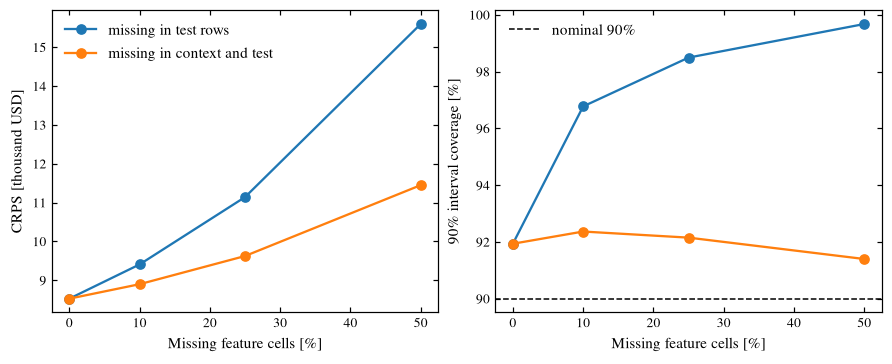

In [9]:
percent = 100 * np.array(fractions)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2), layout="constrained")
for scores, label in [(test_only, "test rows"), (both, "context and test")]:
    axes[0].plot(percent, scores[:, 0], "o-", label=f"missing in {label}")
    axes[1].plot(percent, 100 * scores[:, 1], "o-")
axes[1].axhline(90, color="k", ls="--", lw=1, label="nominal 90%")
axes[0].set_ylabel("CRPS [thousand USD]")
axes[1].set_ylabel("90% interval coverage [%]")
for ax in axes:
    ax.set_xlabel("Missing feature cells [%]")
axes[0].legend()
axes[1].legend()
plt.show()

In [10]:
print("missing  CRPS (test, both)  coverage (test, both)")
for f, (c1, v1), (c2, v2) in zip(fractions, test_only, both):
    print(f"{f:6.0%}   {c1:6.2f} {c2:6.2f}       {v1:6.1%} {v2:6.1%}")

missing  CRPS (test, both)  coverage (test, both)
    0%     8.52   8.52        91.9%  91.9%
   10%     9.41   8.90        96.8%  92.4%
   25%    11.14   9.62        98.5%  92.2%
   50%    15.60  11.45        99.7%  91.4%


The figure shows the CRPS (left) and the coverage of the 90% interval
(right) as a function of the fraction of feature cells we removed, and the
table gives the same numbers. With no missing values, the CRPS is 8.52
thousand USD, and 91.9% of the true prices fall inside the 90% interval.
When the cells are missing from the test rows only, the CRPS grows to 15.60
thousand USD at 50%, and the coverage rises to 99.7%, so the model answers
the missing cells with distributions that are wider than they need to be.
When the context has the same gaps, the CRPS grows less (11.45 vs 15.60
thousand USD at 50%), and the coverage stays between 91.4% and 92.4%.
This might be because a context with
missing cells shows the model how much the price varies when part of a
house's description is unknown, which a complete context cannot. While we
removed the cells at random here, which real gaps rarely are, this suggests
that a context with the same kind of gaps as the rows to be predicted is
better than one of complete rows only.

## Column names and order

When the features have column names, `fit` records them as
`feature_names_in_` and checks them at prediction time. The encoder puts the
categorical columns first, so these are the names the model saw.

In [11]:
lazy_model = model[-1]
lazy_model.feature_names_in_[:5]

array(['MS_SubClass', 'MS_Zoning', 'Street', 'Alley', 'Lot_Shape'],
      dtype=object)

The same columns in a different order are put back in the order of `fit`
before the model sees them, so reversing the columns of the encoded test
set leaves the predictions unchanged. A table without names (here a NumPy
array) is used by position, with a warning.

In [12]:
X_encoded = model[:-1].transform(X_test)
reversed_columns = X_encoded[X_encoded.columns[::-1]]
same = np.array_equal(
    lazy_model.predict(X_encoded), lazy_model.predict(reversed_columns)
)
print("Same predictions with the columns reversed:", same)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    lazy_model.predict(X_encoded.to_numpy())
print(caught[-1].message)

Same predictions with the columns reversed: True


X does not have valid feature names, but LazyModel was fitted with feature names; using columns by position


Besides pandas DataFrames, the features can be NumPy arrays, structured
arrays or astropy tables (whose masked entries also become `NaN`), and
anything with a `to_pandas()` method.

For the next steps, we suggest the following pages:

- [One interface for every model](https://lazy-tfm.readthedocs.io/en/latest/guide/interface.html):
  the input formats and how each model treats missing values.
- [Limits](https://lazy-tfm.readthedocs.io/en/latest/guide/limits.html):
  categorical columns and other cases to watch for.
- [Basic usage](https://lazy-tfm.readthedocs.io/en/latest/tutorials/basic_usage.html):
  the full workflow, from `fit` to the metrics.